# Clase 2

## 1 y 2 

In [ ]:
import pandas as pd


In [6]:
df = pd.read_csv('GLT_filtrado.csv', encoding='utf-8')
df

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W
...,...,...,...,...,...,...,...
219570,2012-08-01,23.885,0.435,Xian,China,34.56N,108.97E
219571,2012-09-01,17.028,1.405,Xian,China,34.56N,108.97E
219572,2012-10-01,12.399,0.526,Xian,China,34.56N,108.97E
219573,2012-11-01,4.736,0.519,Xian,China,34.56N,108.97E


In [7]:
df.head()
#Muestra las primeras filas del Dataframe

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W


In [10]:
df.shape
#Para saber que  cuantas filas y columnas hay (en ese orden)

(219575, 7)

In [12]:
df['City'].nunique()
#df --> data frame 
#['City']--> seleccionamos solamente la columna City 
# .nunique() cuanta cuantos valores unicos hay 

100

In [17]:
df.dtypes
#Que tipos de datos contiene el dataframe

Date                                 str
AverageTemperature               float64
AverageTemperatureUncertainty    float64
City                                 str
Country                              str
Latitude                             str
Longitude                            str
dtype: object

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 219575 entries, 0 to 219574
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           219575 non-null  str    
 1   AverageTemperature             191994 non-null  float64
 2   AverageTemperatureUncertainty  191994 non-null  float64
 3   City                           219575 non-null  str    
 4   Country                        219575 non-null  str    
 5   Latitude                       219575 non-null  str    
 6   Longitude                      219575 non-null  str    
dtypes: float64(2), str(5)
memory usage: 11.7 MB


In [19]:
df.isna().sum()
#.isna busca si hay un dato faltante, si hay texto false y si no hay true , (0 y 1) , sum suma los valores de isna
# porlo que contramos cuantos datos faltantes hay

Date                                 0
AverageTemperature               27581
AverageTemperatureUncertainty    27581
City                                 0
Country                              0
Latitude                             0
Longitude                            0
dtype: int64

## 3. Convierte la columna Date de texto a una fecha (datetime) para poder trabajar con a ̃nos, meses, ordenar por tiempo, etc., y crea una nueva columna Year extrayendo el a ̃no de cada fecha.

In [25]:

df['Date'] = pd.to_datetime(df['Date'])
## Selecciona ['Date']  pd.to_datatime (df['Date'])---> convierte a el tipo de dato a fechas y los sustituimos con =
df['Year'] = df['Date'].dt.year
## usamos .dt.year commo datatime--> .year años es decir obtenemos el años y se agrega como una nueva columna
df.head()

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,1849


In [27]:
df.shape

(219575, 8)

## 4. Filtra una ciudad (por ejemplo, México):

In [30]:
ciudad =  'Mexico'    #Una variable que definimos ocmo mexico pero puede ser madrid , tokyo o algun otro
d=  df[df['City']==ciudad]  # en nuestro df seleccionamos la columna ciudad  y lo comparamos == con nuestra variables
# y solo tenemos solo las columnas con ese valor
print("Filas:", len(d))



Filas: 2136


## 5. Calcula la temperatura media anual:

In [31]:
media_anual=d.groupby('Year')['AverageTemperature'].mean()
# .groundby agrupa terminos iguales (agrupar por:) , despues se queda con la columna AverageTemperatura y .mean calcula el promedio
print(media_anual.head())

Year
1835    13.847818
1836    15.465200
1837    14.822583
1838    14.480333
1839    14.575444
Name: AverageTemperature, dtype: float64


## 6. Grafica el resultado:

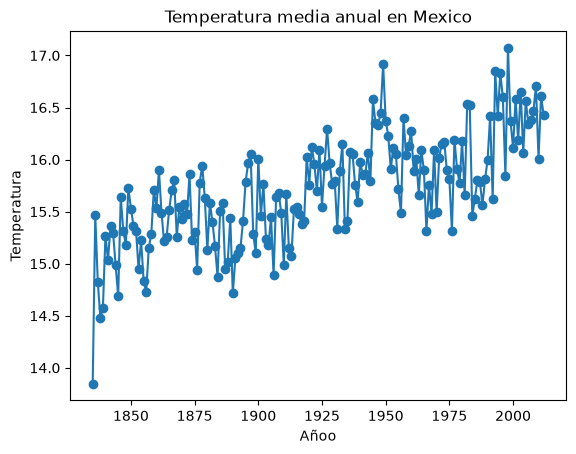

In [40]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(media_anual.index, media_anual.values,marker='o')
# plt.plot (x,y) , el maker es el dibujo donde pone cada dato
plt.title(f'Temperatura media anual en Mexico')
plt.xlabel('Añoo')
plt.ylabel('Temperatura')
plt.show() # Muestra la grafica